# Who spent the forty thousand?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/warehouse-cost-attribution/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/warehouse-cost-attribution/demo.ipynb)

**A warehouse invoice is a joint cost, and a joint cost has no unique owner.**

Finance forwards the bill and asks which team spent it. The question sounds like accounting
and is not: three ordinary features of a warehouse make the cost genuinely *joint*, and once
a cost is joint, "who spent it" has a menu of correct answers rather than one.

| # | question | the finding |
|---|---|---|
| 1 | Where does the bill come from? | storage paid once, models built once, a floor owed by everyone |
| 2 | What do the usual rules say? | seven defensible rules, one team billed $32 or $5,092 |
| 3 | Charge what each team costs you? | recovers **10%** of the invoice |
| 4 | Charge what each would cost alone? | recovers **325%** |
| 5 | Use the principled answer? | Shapley, exact over 720 orderings |
| 6 | Does game theory settle it? | the core is non-empty and **72% of the invoice wide** |
| 7 | Cancel the jobs nobody owns? | charged $7,292, saves $430 — **17x apart** |
| 8 | Is exact Shapley worth building? | no — sample it |

Everything runs from numpy and scipy. Nothing is asserted that is not computed in front of you.

## 1. A month with a known answer

Six teams share ten tables, three upstream models and one reservation. Three things make the
cost joint, and all three are ordinary:

1. **cache** — the second read of a table that day costs 2% of the first, so what a query
   costs depends on who else ran;
2. **shared builds** — an upstream model is built once and consumed by everyone who needs it;
3. **reservation** — a fixed floor owed the moment *anybody* uses the warehouse.

Everything downstream comes from one function: `v(S)`, the invoice that coalition `S` would
have generated on its own.

In [1]:
from __future__ import annotations
import itertools, math
import numpy as np

SCAN_RATE      = 5.00 / 1024   # $ per GB scanned ($5/TB)
STORAGE_RATE   = 0.020         # $ per GB-month
CACHE_RATE     = 0.02          # a cached re-read costs 2% of a scan
RESERVED_FLOOR = 5_200.00      # $/month, owed the moment anyone uses the warehouse
WORKDAYS       = 22
COLD_SLOTS     = 4             # distinct query shapes per table per day that miss the cache

TABLES = {  # name: (scan_gb, storage_gb)
    "events_raw": (9800.0, 214_000.0), "sessions": (3100.0, 61_000.0),
    "orders": (620.0, 14_500.0),       "customers": (210.0, 4_800.0),
    "subscriptions": (340.0, 7_100.0), "marketing_touch": (4200.0, 78_000.0),
    "ledger": (150.0, 3_900.0),        "feature_store": (6400.0, 131_000.0),
    "support_tickets": (280.0, 5_200.0), "experiment_assign": (2600.0, 47_000.0),
}
MODELS = [  # (name, build_gb, consumers)
    ("dim_customer",  1400.0, {"analytics", "growth", "finance", "exec_reporting"}),
    ("fct_orders",    2100.0, {"analytics", "finance", "exec_reporting"}),
    ("user_features", 5300.0, {"ml_platform", "growth"}),
]
TEAMS = {
    "analytics":      {"events_raw":260, "sessions":180, "orders":140, "customers":90,
                       "experiment_assign":60},
    "growth":         {"events_raw":310, "marketing_touch":220, "sessions":120,
                       "experiment_assign":190},
    "finance":        {"orders":110, "ledger":240, "subscriptions":130, "customers":40},
    "ml_platform":    {"feature_store":340, "events_raw":150, "sessions":90},
    "exec_reporting": {"orders":30, "customers":25, "subscriptions":20, "ledger":15},
    "scheduled_unowned": {"events_raw":120, "marketing_touch":130, "support_tickets":95,
                          "feature_store":60},
}
NAMES = list(TEAMS)

def coalition_cost(members):
    """The invoice this coalition would have generated ON ITS OWN. Not additive."""
    members = list(members)
    if not members:
        return 0.0
    reads = {}
    for m in members:
        for tb, n in TEAMS[m].items():
            reads[tb] = reads.get(tb, 0) + n
    total = RESERVED_FLOOR
    for tb, r in reads.items():
        scan_gb, storage_gb = TABLES[tb]
        cold = min(r, WORKDAYS * COLD_SLOTS)          # the rest hit the cache
        total += cold * scan_gb * SCAN_RATE
        total += (r - cold) * scan_gb * SCAN_RATE * CACHE_RATE
        total += storage_gb * STORAGE_RATE            # stored because SOMEBODY needs it
    live = set(members)
    for _, build_gb, consumers in MODELS:
        if consumers & live:                          # built once, for whoever needs it
            total += WORKDAYS * build_gb * SCAN_RATE
    return total

INVOICE = coalition_cost(NAMES)
v = coalition_cost
print(f"the invoice: ${INVOICE:,.2f}")
print(f"  reservation floor: ${RESERVED_FLOOR:,.0f}  ({RESERVED_FLOOR/INVOICE:.0%} of it)")

the invoice: $30,550.06
  reservation floor: $5,200  (17% of it)


The single most important property: **the cost function is not additive.** Add up what each
team would have cost on its own and you get more than three times the actual bill. The gap
is the value of sharing, and it does not belong to anybody in particular.

In [2]:
standalone = {n: v([n]) for n in NAMES}
marginal   = {n: INVOICE - v([m for m in NAMES if m != n]) for n in NAMES}

print(f"{'team':20} {'standalone':>12} {'marginal':>10}")
for n in NAMES:
    print(f"{n:20} {standalone[n]:12,.0f} {marginal[n]:10,.0f}")
print(f"{'TOTAL':20} {sum(standalone.values()):12,.0f} {sum(marginal.values()):10,.0f}")
print(f"\ninvoice{'':13} {INVOICE:12,.0f}")
print(f"\nstandalone recovers {sum(standalone.values())/INVOICE:6.1%} of the invoice")
print(f"marginal   recovers {sum(marginal.values())/INVOICE:6.1%} of the invoice")
print(f"\nthe value of sharing = ${sum(standalone.values())-INVOICE:,.0f}, owned by nobody")

team                   standalone   marginal
analytics                  19,259        352
growth                     22,687        820
finance                     6,705        178
ml_platform                22,400      1,241
exec_reporting              6,343          3
scheduled_unowned          21,823        430
TOTAL                      99,216      3,024

invoice                    30,550

standalone recovers 324.8% of the invoice
marginal   recovers   9.9% of the invoice

the value of sharing = $68,666, owned by nobody


Read that again, because it is the whole problem in two numbers.

**Charge every team exactly what it costs you** — the most defensible number in the building,
the amount that stops being spent if they stop querying — and you collect **10%** of the
invoice. 90% of the bill has no payer.

**Charge every team what it would cost alone** — also true, also defensible — and you collect
**325%**.

No allocation is both defensible per team and exact in total. That is not a modelling
artefact; it is what "joint" means.

## 2. Seven defensible rules, one invoice

Each of these is a sentence somebody says out loud in a cost review. Each bills the full
invoice. They disagree wildly.

In [3]:
def normalise(shares):
    s = sum(shares.values())
    return {k: val * INVOICE / s for k, val in shares.items()}

def direct_bytes():
    return normalise({n: sum(TABLES[tb][0]*c for tb, c in TEAMS[n].items()) for n in NAMES})

def query_count():
    return normalise({n: float(sum(TEAMS[n].values())) for n in NAMES})

def equal_split():
    return {n: INVOICE/len(NAMES) for n in NAMES}

def m_standalone(): return normalise(dict(standalone))
def m_marginal():   return normalise(dict(marginal))

def shapley():
    """Average marginal contribution over all 720 orderings. Exact, not sampled."""
    phi = {n: 0.0 for n in NAMES}
    for order in itertools.permutations(NAMES):
        run, prev = [], 0.0
        for n in order:
            run.append(n); cur = v(run); phi[n] += cur - prev; prev = cur
    f = math.factorial(len(NAMES))
    return {k: val/f for k, val in phi.items()}

METHODS = {"direct_bytes": direct_bytes, "query_count": query_count,
           "equal_split": equal_split, "standalone": m_standalone,
           "marginal": m_marginal, "shapley": shapley}
allocs = {m: f() for m, f in METHODS.items()}

print(f"{'method':14} " + " ".join(f"{n[:9]:>9}" for n in NAMES))
for m, a in allocs.items():
    print(f"{m:14} " + " ".join(f"{a[n]:9,.0f}" for n in NAMES))

print(f"\n{'team':20} {'min':>9} {'max':>9} {'ratio':>8}")
for n in NAMES:
    vals = [allocs[m][n] for m in allocs]
    print(f"{n:20} {min(vals):9,.0f} {max(vals):9,.0f} {max(vals)/max(min(vals),1):7.0f}x")

tops = {m: max(a, key=lambda k: a[k]) for m, a in allocs.items()}
print(f"\nMOST EXPENSIVE TEAM, by method: {sorted(set(tops.values()))}")

method         analytics    growth   finance ml_platfo exec_repo scheduled
direct_bytes       7,123    10,212       332     8,302        70     4,511
query_count        7,046     8,108     5,019     5,598       869     3,909
equal_split        5,092     5,092     5,092     5,092     5,092     5,092
standalone         5,930     6,986     2,065     6,897     1,953     6,720
marginal           3,556     8,282     1,802    12,534        32     4,345
shapley            5,395     7,460     1,554     7,564     1,285     7,292

team                       min       max    ratio
analytics                3,556     7,123       2x
growth                   5,092    10,212       2x
finance                    332     5,092      15x
ml_platform              5,092    12,534       2x
exec_reporting              32     5,092     157x
scheduled_unowned        3,909     7,292       2x

MOST EXPENSIVE TEAM, by method: ['analytics', 'growth', 'ml_platform']


`exec_reporting` is billed anywhere from tens of dollars to thousands depending on nothing
but which sentence was said in the meeting.

And note the last line. The single most consequential output of a cost review — **which team
to go and talk to** — has three different answers across six rules that are all defensible.

## 3. Does game theory settle it?

Cooperative game theory has a strongest-possible fairness test: the **core**, the set of
allocations where no group of teams is asked to pay more than that group would have cost on
its own. Anything in the core is an allocation nobody has grounds to walk out of.

It is a linear program, so we can ask not just whether it is non-empty but **how wide it is**.

In [4]:
from scipy.optimize import linprog

def coalitions():
    for k in range(len(NAMES)+1):
        yield from itertools.combinations(NAMES, k)

def core_constraints():
    idx = {n:i for i,n in enumerate(NAMES)}
    A, b = [], []
    for S in coalitions():
        if not S or len(S) == len(NAMES):
            continue
        row = np.zeros(len(NAMES))
        for n in S: row[idx[n]] = 1.0
        A.append(row); b.append(v(S))
    return np.array(A), np.array(b)

A, b = core_constraints()
Aeq, beq = np.ones((1, len(NAMES))), [INVOICE]
bounds = [(0, None)]*len(NAMES)

feasible = linprog(np.zeros(len(NAMES)), A_ub=A, b_ub=b, A_eq=Aeq, b_eq=beq,
                   bounds=bounds, method="highs")
print("core non-empty:", feasible.success, "\n")

sh = shapley()
print(f"{'team':20} {'core min':>10} {'core max':>10} {'width':>10} {'% invoice':>10} {'shapley':>9}")
for i, n in enumerate(NAMES):
    c = np.zeros(len(NAMES)); c[i] = 1.0
    lo = linprog(c,  A_ub=A, b_ub=b, A_eq=Aeq, b_eq=beq, bounds=bounds, method="highs").x[i]
    hi = linprog(-c, A_ub=A, b_ub=b, A_eq=Aeq, b_eq=beq, bounds=bounds, method="highs").x[i]
    print(f"{n:20} {lo:10,.0f} {hi:10,.0f} {hi-lo:10,.0f} {(hi-lo)/INVOICE:9.0%} {sh[n]:9,.0f}")

core non-empty: True 

team                   core min   core max      width  % invoice   shapley
analytics                   352     19,259     18,907       62%     5,395
growth                      820     22,687     21,867       72%     7,460
finance                     178      6,705      6,527       21%     1,554
ml_platform               1,241     22,400     21,159       69%     7,564
exec_reporting                3      6,343      6,339       21%     1,285
scheduled_unowned           430     21,823     21,393       70%     7,292


The core is non-empty, and **up to 72% of the invoice wide per team**. `growth` could be
billed $820 or $22,687 and nobody would have grounds to object either way.

So "fair" is not a point. It is a polytope, and it is nearly as wide as the bill.

What the core *does* do is reject the two rules people reach for first — and it rejects them
as **coalitions**, not individuals, which is why nobody notices.

In [5]:
def in_core(alloc, tol=1e-6):
    if abs(sum(alloc.values()) - INVOICE) > 1e-4:
        return False, None
    worst = None
    for S in coalitions():
        if not S or len(S) == len(NAMES):
            continue
        excess = sum(alloc[n] for n in S) - v(S)
        if excess > tol and (worst is None or excess > worst[1]):
            worst = (S, excess)
    return worst is None, worst

for m, a in allocs.items():
    ok, worst = in_core(a)
    if ok:
        print(f"{m:14} in core")
    else:
        S, ex = worst
        print(f"{m:14} REJECTED - {{{', '.join(S)}}} would object by ${ex:,.0f}")

direct_bytes   REJECTED - {analytics, growth, ml_platform, scheduled_unowned} would object by $44
query_count    in core
equal_split    REJECTED - {finance, exec_reporting} would object by $3,450
standalone     in core
marginal       in core
shapley        in core


`equal_split` — six teams, six ways — is rejected because finance and exec_reporting
*together* would rather leave and run their own warehouse than pay a sixth each. Nobody
objects individually, so the objection never surfaces in the meeting.

Everything else survives, and the survivors still disagree by ~60x on a single team. The
strongest fairness test in the theory is a real filter and a weak one.

## 4. The jobs nobody owns

The most actionable-looking line in any cost review is the orphaned scheduled jobs. Here are
two correct numbers about them that point in opposite directions.

In [6]:
owned = [n for n in NAMES if n != "scheduled_unowned"]
saving = INVOICE - v(owned)
print(f"Shapley says the orphaned jobs consume   ${sh['scheduled_unowned']:9,.0f}  "
      f"({sh['scheduled_unowned']/INVOICE:.0%} of the invoice)")
print(f"Switching them off would actually save   ${saving:9,.0f}  "
      f"({saving/INVOICE:.1%} of the invoice)")
print(f"                                          {sh['scheduled_unowned']/saving:9,.0f}x apart")

Shapley says the orphaned jobs consume   $    7,292  (24% of the invoice)
Switching them off would actually save   $      430  (1.4% of the invoice)
                                                 17x apart


Both are true. The jobs really do consume a quarter of the warehouse by any consumption
measure, and turning them off really would save almost nothing — because everything they
read is read by somebody else anyway, so the scan still happens and the storage is still paid.

**Attribution answers "who consumed it". It does not answer "what would we save."** A cost
review that acts on the first number cancels the jobs and never sees the saving.

## 5. The picture

Two panels: how far apart the rules are, and how wide "fair" is.

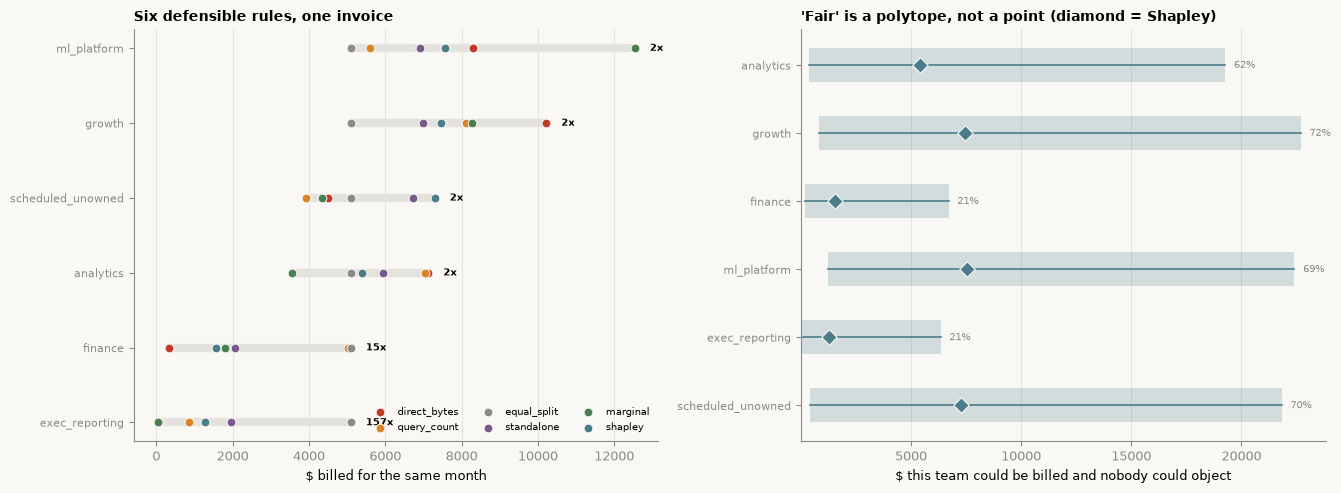

In [7]:
import matplotlib.pyplot as plt

INK, MUTED, GRID, PAPER = "#141414", "#8a8a8a", "#e4e2dd", "#faf8f4"
RED, ORANGE, BLUE, GREEN, PURPLE = "#c0392b", "#d98324", "#4a7c8c", "#4b7f52", "#7a5a8c"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED})
COL = {"direct_bytes": RED, "query_count": ORANGE, "equal_split": MUTED,
       "standalone": PURPLE, "marginal": GREEN, "shapley": BLUE}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.0))

order = sorted(NAMES, key=lambda t: -max(allocs[m][t] for m in allocs))
for i, t in enumerate(order):
    vals = [allocs[m][t] for m in allocs]
    ax1.plot([min(vals), max(vals)], [i, i], color=GRID, lw=6, solid_capstyle="round")
    for m in allocs:
        ax1.scatter(allocs[m][t], i, s=40, color=COL[m], zorder=3, edgecolor=PAPER,
                    linewidth=0.7, label=m if i == 0 else None)
    ax1.text(max(vals)+400, i, f"{max(vals)/max(min(vals),1):.0f}x", va="center",
             fontsize=7.5, fontweight="bold")
ax1.set_yticks(range(len(order))); ax1.set_yticklabels(order, fontsize=8)
ax1.invert_yaxis(); ax1.set_xlabel("$ billed for the same month")
ax1.legend(frameon=False, fontsize=7, ncol=3, loc="lower right")
ax1.set_title("Six defensible rules, one invoice", loc="left", fontweight="bold", fontsize=10)
ax1.grid(axis="x", color=GRID, lw=0.7); ax1.set_axisbelow(True)

for i, n in enumerate(NAMES):
    c = np.zeros(len(NAMES)); c[i] = 1.0
    lo = linprog(c,  A_ub=A, b_ub=b, A_eq=Aeq, b_eq=beq, bounds=bounds, method="highs").x[i]
    hi = linprog(-c, A_ub=A, b_ub=b, A_eq=Aeq, b_eq=beq, bounds=bounds, method="highs").x[i]
    ax2.barh(i, hi-lo, left=lo, height=0.5, color=BLUE, alpha=0.22)
    ax2.plot([lo, hi], [i, i], color=BLUE, lw=1.2)
    ax2.scatter(sh[n], i, s=62, marker="D", color=BLUE, zorder=4, edgecolor=PAPER, linewidth=0.8)
    ax2.text(hi+400, i, f"{(hi-lo)/INVOICE:.0%}", va="center", fontsize=7.5, color=MUTED)
ax2.set_yticks(range(len(NAMES))); ax2.set_yticklabels(NAMES, fontsize=8)
ax2.invert_yaxis(); ax2.set_xlabel("$ this team could be billed and nobody could object")
ax2.set_title("'Fair' is a polytope, not a point (diamond = Shapley)", loc="left",
              fontweight="bold", fontsize=10)
ax2.grid(axis="x", color=GRID, lw=0.7); ax2.set_axisbelow(True)

plt.tight_layout(); plt.savefig("cost_notebook.png", dpi=150); plt.show()

## 6. Is the principled answer worth building?

Shapley needs 2^n coalition evaluations. Six teams is 64; thirty teams is a billion. Before
building the exact version, check whether sampling gets you there.

In [8]:
def sampled_shapley(draws, seed=1):
    rng = np.random.default_rng(seed)
    phi = {n: 0.0 for n in NAMES}
    for _ in range(draws):
        run, prev = [], 0.0
        for n in rng.permutation(NAMES):
            run.append(str(n)); cur = v(run); phi[str(n)] += cur - prev; prev = cur
    return {k: val/draws for k, val in phi.items()}

print(f"{'orderings':>10} {'max error':>11} {'% of invoice':>13}")
for m in [50, 200, 1_000, 5_000]:
    s = sampled_shapley(m)
    err = max(abs(s[n]-sh[n]) for n in NAMES)
    print(f"{m:10,} {err:11,.0f} {err/INVOICE:12.2%}")

print("\nhow far each cheap rule sits from Shapley:")
for m, a in allocs.items():
    if m == "shapley": continue
    print(f"  {m:14} {max(abs(a[n]-sh[n]) for n in NAMES)/INVOICE:6.1%} of the invoice")

 orderings   max error  % of invoice
        50       2,940        9.62%
       200         803        2.63%
     1,000         366        1.20%
     5,000         162        0.53%

how far each cheap rule sits from Shapley:
  direct_bytes     9.1% of the invoice
  query_count     11.3% of the invoice
  equal_split     12.5% of the invoice
  standalone       2.2% of the invoice
  marginal        16.3% of the invoice


**Negative result:** a few thousand sampled orderings land within 1% of the exact value. The
2^n objection to Shapley is real in complexity and mostly irrelevant in practice — do *not*
build the exact version for a warehouse with thirty teams, sample it.

And no cheap rule approximates it. The closest is still ~2% of the invoice away on some team,
which is half of the smallest team's entire bill. So the choice is between sampling Shapley
and admitting out loud that you picked a different rule.

## 7. What a cost allocation has to carry

1. **The method, named.** Seven defensible rules name three different teams as the most expensive.
2. **The admission that it cannot add up.** Marginal recovers 10%, standalone 325%.
3. **A range, not a number.** The core is up to 72% of the invoice wide per team.
4. **What it refuses to attribute.** The reservation is 17% of the bill with a marginal cost
   of zero to everyone. Dividing it is a political act, not an accounting one.
5. **The gap between blame and saving.** 17x, on the one line item that looks most actionable.
6. **The incentive it creates.** Charging the cold scan to whoever triggers it pays every team
   50x to wait for somebody else to go first.
7. **Its own cost.** Sample Shapley; do not build the exact one.

## Try your own

Change the world and see which conclusions survive. Some are robust; at least one is not.

In [9]:
# --- 1. Remove the cache. Does the invoice still fail to decompose?
# CACHE_RATE = 1.0   # then re-run coalition_cost and the standalone/marginal cell

# --- 2. Drop the reservation to zero. How much of the core's width was the floor?
# RESERVED_FLOOR = 0.0

# --- 3. Add a team and watch Shapley's cost explode (2^n, and n! orderings).
# TEAMS["data_science"] = {"feature_store": 200, "events_raw": 180, "orders": 40}
# NAMES = list(TEAMS)

# --- 4. The claim most worth attacking: the core is wide BECAUSE sharing is large.
#        Make the teams read disjoint tables so sharing nearly vanishes, then re-run
#        section 3. Prediction: the core collapses towards a point and the methods agree.
#        Check whether it actually does.

---

**Day 161 of [Phoebe's FDE portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — one small, real tool a day.

- Full ten-section study: `python evidence.py`
- The engine, with 32 tests pinning every number: `costs.py`, `test_costs.py`
- Interactive version: `streamlit run app.py`

The notebook above re-implements a compact copy of the engine so it runs standalone on Colab.
`costs.py` in the repo is the authoritative one.